# SOM Topology: Fold Angle Analysis

For each node, the **minimum pairwise angle** between edge vectors to graph neighbors
is computed in weight space. This detects topographic folds.

In a regular 4-connected grid, each interior node has four cardinal-direction
neighbours. Adjacent neighbour vectors (e.g. up + right) span **90°**; opposite
vectors (up + down) span **180°**. The minimum over all pairs is therefore **90°**
for a well-formed interior node.

| Min angle | Interpretation |
|-----------|----------------|
| ~180°     | Chain node (2 roughly opposite neighbours) |
| ~90°      | Interior node, regular 4-grid |
| < 90°     | Compression or distortion |
| < 45°     | Likely fold |
| ~0°       | Collapsed neurons |

**Four examples** with increasing topological difficulty:
1. Well-separated blobs — clean reference
2. Swiss roll — curved 3D manifold
3. Circle — 1D ring, forces wrap-around fold
4. Digits — real high-dimensional data

In [9]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits, make_blobs, make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from dbgsom.SomVQ import SomVQ

In [10]:
def node_fold_angles(som):
    """Min pairwise angle (degrees) between neighbor edge vectors in weight space.

    Returns dict node -> angle. NaN for leaf nodes (< 2 neighbors).
    """
    node_idx = {n: i for i, n in enumerate(som.neurons_)}
    result = {}
    for node in som.neurons_:
        i = node_idx[node]
        nbrs = list(som.som_.neighbors(node))
        if len(nbrs) < 2:
            result[node] = np.nan
            continue
        vecs = np.array([som.weights_[node_idx[nb]] - som.weights_[i] for nb in nbrs])
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        vecs = vecs / np.where(norms > 0, norms, 1.0)
        result[node] = np.min(
            list(
                np.degrees(np.arccos(np.clip(vecs[a] @ vecs[b], -1.0, 1.0)))
                for a, b in combinations(range(len(vecs)), 2)
            )
        )
    return result


def node_topographic_error(som, X):
    """Per-node topographic error: fraction of assigned samples where BMU2 is not a graph neighbour.

    Returns dict node -> TE in [0, 1]. NaN for nodes with no assigned samples.
    """
    _, winners2 = som._get_winning_neurons(X, n_bmu=2)
    bmu1 = winners2[:, 0]
    bmu2 = winners2[:, 1]
    node_idx = {n: i for i, n in enumerate(som.neurons_)}
    result = {}
    for node in som.neurons_:
        i = node_idx[node]
        mask = bmu1 == i
        if not np.any(mask):
            result[node] = np.nan
            continue
        nbr_indices = np.array([node_idx[nb] for nb in som.som_.neighbors(node)])
        violations = int(np.sum(~np.isin(bmu2[mask], nbr_indices)))
        result[node] = violations / int(np.sum(mask))
    return result


def plot_fold_analysis(som, title, X=None):
    """Two- or three-panel plot: fold angle map + histogram [+ per-node TE map].

    Returns (fig, angles_array, te_dict). te_dict is None when X is not provided.
    """
    angles_dict = node_fold_angles(som)
    angles = np.array([angles_dict[n] for n in som.neurons_])

    pca = PCA(n_components=2)
    pos2d = pca.fit_transform(som.weights_)
    node_pos = dict(zip(som.neurons_, pos2d))

    n_panels = 3 if X is not None else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    ax_map, ax_hist = axes[0], axes[1]

    def _draw_edges(ax):
        for u, v in som.som_.edges():
            x0, y0 = node_pos[u]
            x1, y1 = node_pos[v]
            ax.plot([x0, x1], [y0, y1], color="lightgray", lw=0.8, zorder=1)

    _draw_edges(ax_map)
    valid = ~np.isnan(angles)
    sc = ax_map.scatter(
        pos2d[valid, 0],
        pos2d[valid, 1],
        c=angles[valid],
        cmap="magma_r",
        vmin=0,
        vmax=180,
        s=80,
        zorder=2,
        edgecolors="k",
        linewidths=0.3,
    )
    if np.any(~valid):
        ax_map.scatter(
            pos2d[~valid, 0],
            pos2d[~valid, 1],
            c="gray",
            s=80,
            zorder=2,
            label="leaf (1 neighbor)",
        )
        ax_map.legend(fontsize=8)
    plt.colorbar(sc, ax=ax_map, label="Min angle (°)")
    n_folded = int(np.sum(valid & (angles < 45)))
    ax_map.set_title(
        f"{title}\n{som.som_.number_of_nodes()} neurons  |  {n_folded} folded (<45°)",
        fontsize=11,
    )
    ax_map.set_xlabel("PC 1")
    ax_map.set_ylabel("PC 2")

    ax_hist.hist(
        angles[valid], bins=24, range=(0, 180), color="steelblue", edgecolor="white"
    )
    ax_hist.axvline(90, color="orange", ls="--", lw=1.5, label="90° (ideal interior)")
    ax_hist.axvline(45, color="red", ls=":", lw=1.5, label="45° (fold threshold)")
    ax_hist.set_xlabel("Min angle (°)")
    ax_hist.set_ylabel("Node count")
    ax_hist.set_xlim(0, 180)
    ax_hist.legend(fontsize=8)

    te_dict = None
    if X is not None:
        te_dict = node_topographic_error(som, X)
        te_vals = np.array([te_dict[n] for n in som.neurons_])
        ax_te = axes[2]
        _draw_edges(ax_te)
        te_valid = ~np.isnan(te_vals)
        sc2 = ax_te.scatter(
            pos2d[te_valid, 0],
            pos2d[te_valid, 1],
            c=te_vals[te_valid],
            cmap="magma",
            vmin=0,
            vmax=1,
            s=80,
            zorder=2,
            edgecolors="k",
            linewidths=0.3,
        )
        if np.any(~te_valid):
            ax_te.scatter(
                pos2d[~te_valid, 0],
                pos2d[~te_valid, 1],
                c="gray",
                s=40,
                zorder=2,
                label="no samples",
            )
            ax_te.legend(fontsize=8)
        plt.colorbar(sc2, ax=ax_te, label="Per-node TE")
        n_te_nodes = int(np.sum(te_valid & (te_vals > 0)))
        ax_te.set_title(f"Per-node TE\n{n_te_nodes} nodes with TE > 0", fontsize=11)
        ax_te.set_xlabel("PC 1")
        ax_te.set_ylabel("PC 2")

    plt.tight_layout()
    return fig, angles, te_dict

## Example 1 — Well-Separated Blobs

Five Gaussian clusters, low overlap. The SOM should place one or two neurons per cluster
with clean rectangular connections → expect min angles near 90°.

  6%|▌         | 30/500 [00:00<00:00, 1391.99 epochs/s]


QE: 0.1739  TE: 0.0000
Angle stats — min: 14.1°  mean: 120.9°  max: 179.9°


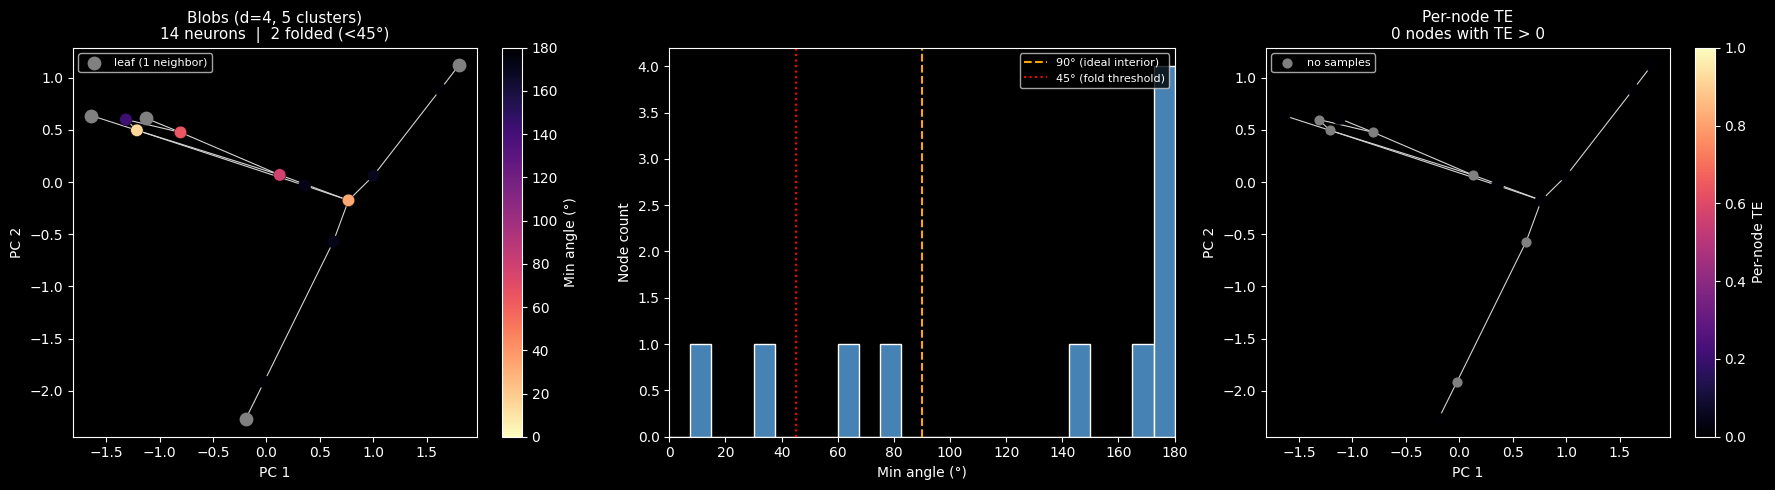

In [11]:
X_blobs, _ = make_blobs(
    n_samples=1000, centers=5, n_features=4, cluster_std=0.5, random_state=42
)
X_blobs = StandardScaler().fit_transform(X_blobs)

som_blobs = SomVQ(
    lambda_=15,
    n_iter=500,
    sigma_end=1,
    random_state=42,
    verbose=True,
)
som_blobs.fit(X_blobs)

fig, angles_blobs, te_blobs = plot_fold_analysis(
    som_blobs, "Blobs (d=4, 5 clusters)", X=X_blobs
)
print(
    f"QE: {som_blobs.quantization_error_:.4f}  TE: {som_blobs.topographic_error_:.4f}"
)
print(
    f"Angle stats — min: {np.nanmin(angles_blobs):.1f}°  mean: {np.nanmean(angles_blobs):.1f}°  max: {np.nanmax(angles_blobs):.1f}°"
)

## Example 2 — Swiss Roll

A 2D manifold coiled in 3D. The SOM must unroll it. Depending on `lambda_` and iteration count,
partial folds can appear where the coil is most tightly wound.

 31%|███▏      | 157/500 [00:00<00:00, 1252.80 epochs/s]


QE: 0.4876  TE: 0.0590
Angle stats — min: 38.5°  mean: 71.9°  max: 141.1°


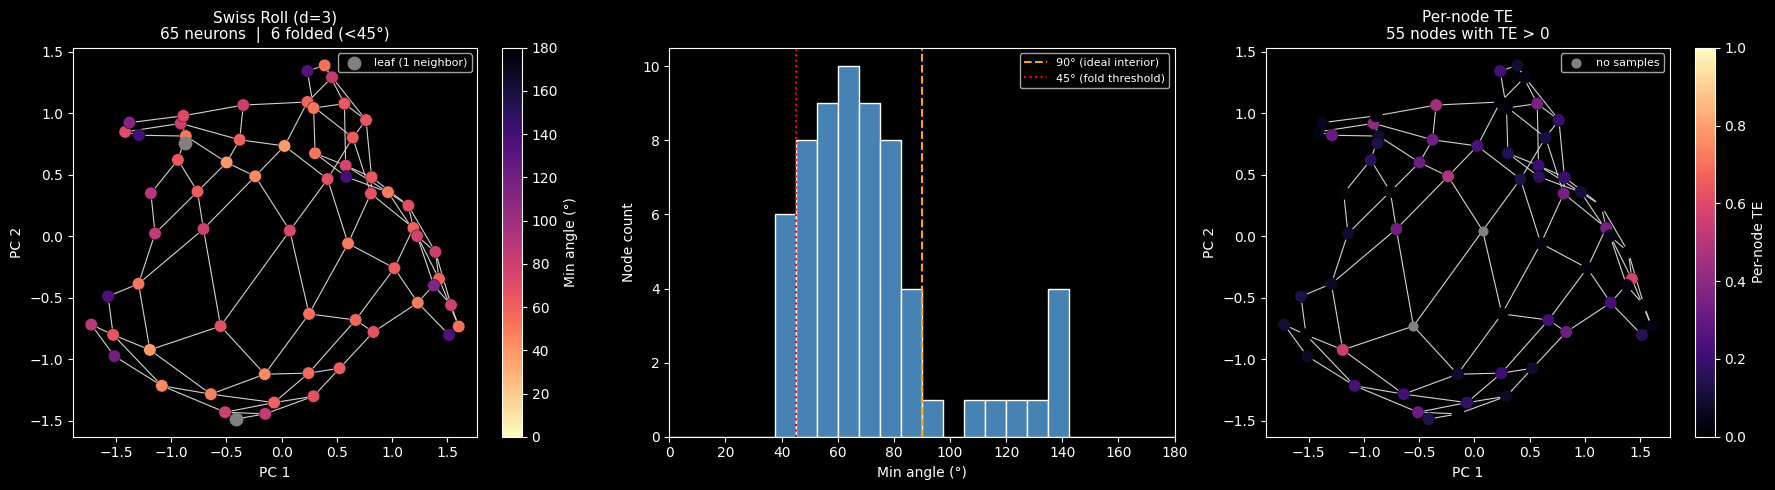

In [12]:
X_roll, _ = make_swiss_roll(n_samples=2000, noise=0.3, random_state=42)
X_roll = StandardScaler().fit_transform(X_roll)

som_roll = SomVQ(
    lambda_=20,
    n_iter=500,
    sigma_end=1,
    random_state=42,
    verbose=True,
)
som_roll.fit(X_roll)

fig, angles_roll, te_roll = plot_fold_analysis(som_roll, "Swiss Roll (d=3)", X=X_roll)
print(f"QE: {som_roll.quantization_error_:.4f}  TE: {som_roll.topographic_error_:.4f}")
print(
    f"Angle stats — min: {np.nanmin(angles_roll):.1f}°  mean: {np.nanmean(angles_roll):.1f}°  max: {np.nanmax(angles_roll):.1f}°"
)

## Example 3 — Circle (Forced Fold)

Points on a 1D ring embedded in 2D. The data has **toroidal topology**: the ring wraps around,
but the SOM has rectangular (non-periodic) boundary conditions. The SOM must fold one edge
to cover the wrap-around — guaranteed fold visible as a low-angle node cluster.

 21%|██        | 104/500 [00:00<00:00, 1938.95 epochs/s]


QE: 0.1838  TE: 0.0290
Angle stats — min: 18.0°  mean: 85.3°  max: 157.7°


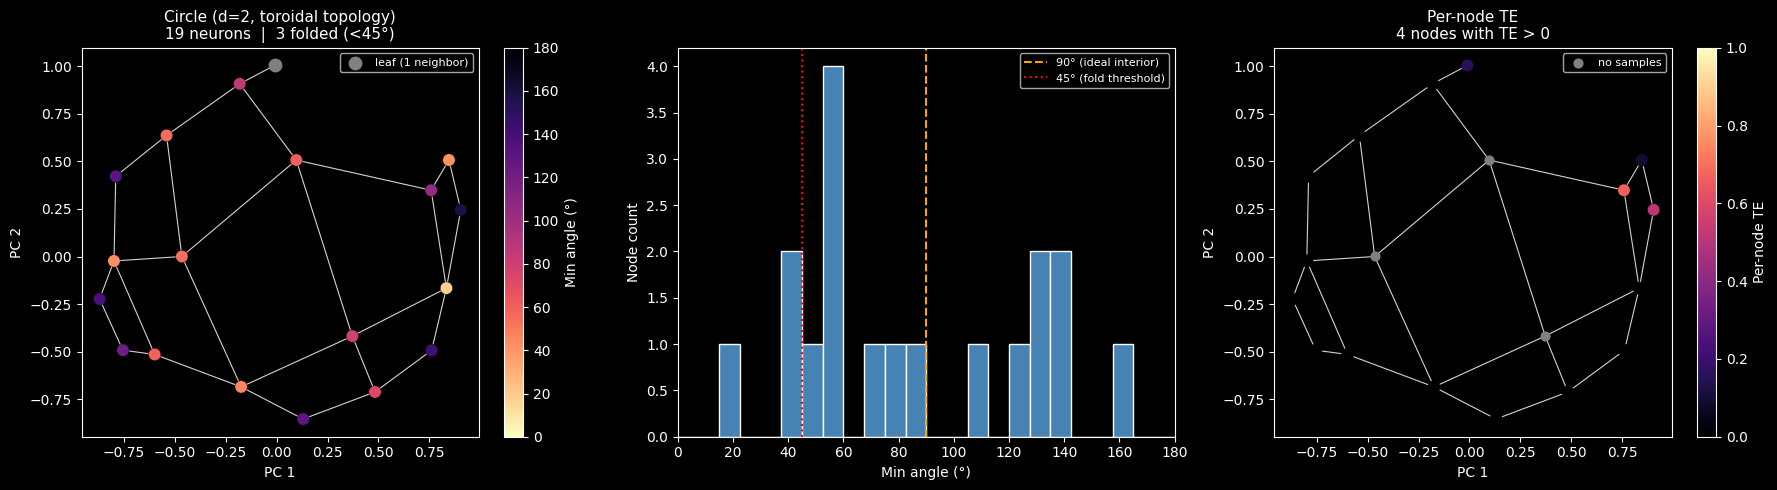

In [13]:
rng = np.random.default_rng(42)
theta = rng.uniform(0, 2 * np.pi, 1000)
X_circle = np.column_stack([np.cos(theta), np.sin(theta)]) + rng.normal(
    0, 0.05, (1000, 2)
)

som_circle = SomVQ(
    lambda_=15.8,
    n_iter=500,
    sigma_end=1,
    random_state=42,
    verbose=True,
)
som_circle.fit(X_circle)

fig, angles_circle, te_circle = plot_fold_analysis(
    som_circle, "Circle (d=2, toroidal topology)", X=X_circle
)
print(
    f"QE: {som_circle.quantization_error_:.4f}  TE: {som_circle.topographic_error_:.4f}"
)
print(
    f"Angle stats — min: {np.nanmin(angles_circle):.1f}°  mean: {np.nanmean(angles_circle):.1f}°  max: {np.nanmax(angles_circle):.1f}°"
)

## Example 4 — Digits (High-Dimensional)

64-dimensional data, 10 classes. The SOM must embed a complex high-dimensional structure
into a planar graph — some folding expected at class boundaries.

 33%|███▎      | 163/500 [00:00<00:00, 1166.24 epochs/s]


QE: 4.7900  TE: 0.0540
Angle stats — min: 22.9°  mean: 74.9°  max: 168.5°


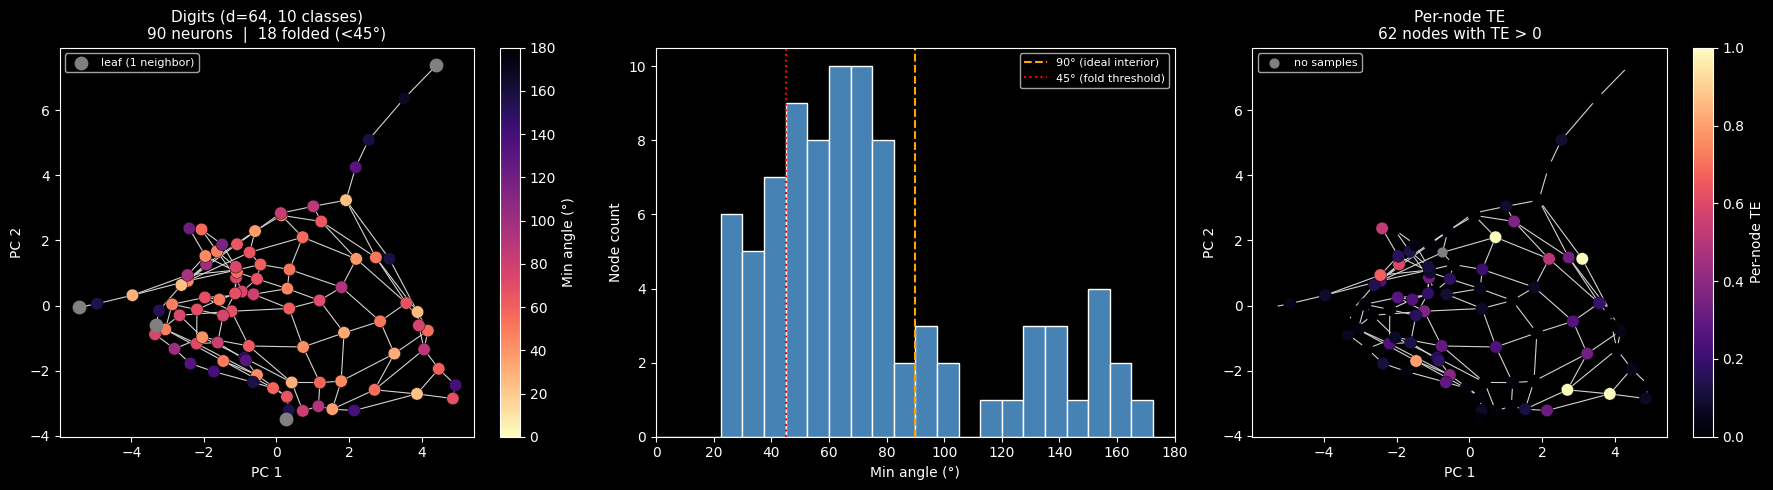

In [14]:
X_digits, y_digits = load_digits(return_X_y=True)
X_digits = StandardScaler().fit_transform(X_digits)

som_digits = som = SomVQ(
    lambda_=30,
    n_iter=500,
    sigma_end=1,
    random_state=42,
    verbose=True,
)
som_digits.fit(X_digits)

fig, angles_digits, te_digits = plot_fold_analysis(
    som_digits, "Digits (d=64, 10 classes)", X=X_digits
)
print(
    f"QE: {som_digits.quantization_error_:.4f}  TE: {som_digits.topographic_error_:.4f}"
)
print(
    f"Angle stats — min: {np.nanmin(angles_digits):.1f}°  mean: {np.nanmean(angles_digits):.1f}°  max: {np.nanmax(angles_digits):.1f}°"
)

## Comparison Across Examples

In [15]:
import pandas as pd

rows = []
for label, som, angles, te_dict in [
    ("Blobs", som_blobs, angles_blobs, te_blobs),
    ("Swiss Roll", som_roll, angles_roll, te_roll),
    ("Circle", som_circle, angles_circle, te_circle),
    ("Digits", som_digits, angles_digits, te_digits),
]:
    valid_a = angles[~np.isnan(angles)]
    te_vals = np.array([te_dict[n] for n in som.neurons_])
    te_valid = te_vals[~np.isnan(te_vals)]
    rows.append(
        {
            "Dataset": label,
            "Neurons": som.som_.number_of_nodes(),
            "QE": f"{som.quantization_error_:.4f}",
            "TE (global)": f"{som.topographic_error_:.4f}",
            "Mean angle (°)": f"{np.mean(valid_a):.1f}",
            "Min angle (°)": f"{np.min(valid_a):.1f}",
            "Folded (<45°)": int(np.sum(valid_a < 45)),
            "Mean node-TE": f"{np.mean(te_valid):.3f}",
            "Nodes TE>0": int(np.sum(te_valid > 0)),
        }
    )

pd.DataFrame(rows).set_index("Dataset")

,Neurons,QE,TE (global),Mean angle (°),Min angle (°),Folded (<45°),Mean node-TE,Nodes TE>0
Dataset,,,,,,,,
Blobs,14,0.1739,0.0000,120.9,14.1,2,0.000,0
Swiss Roll,65,0.4876,0.0590,71.9,38.5,6,0.162,55
Circle,19,0.1838,0.0290,85.3,18.0,3,0.089,4
Digits,90,4.7900,0.0540,74.9,22.9,18,0.170,62


## Discussion — Experimental Metrics

> **Note:** Both metrics in this notebook are experimental and not part of the
> standard DBGSOM API. They are provided here for exploratory topology analysis.

### Fold Angle (this notebook)

The **minimum pairwise angle** between neighbour edge vectors in weight space is a
purely geometric, post-hoc measure. It requires only the trained weights and graph
structure — no original data needed.

| Min angle | Interpretation |
|-----------|----------------|
| ~90° | Interior node, regular 4-grid (adjacent cardinal vectors) |
| ~180° | Chain node (2 roughly opposite neighbours) |
| < 90° | Compression or distortion |
| < 45° | Likely topographic fold |

This metric has no direct equivalent in the published SOM literature. The closest
formal framework is the **topographic function** (Villmann et al., 1997), which defines
topology preservation via the *induced Delaunay triangulation* D_M of the weight vectors.
A fold occurs when lattice-adjacent neurons are not Delaunay-adjacent in weight space —
geometrically this means an intermediate neuron lies between their weight vectors,
causing neighbour edge vectors to point in similar directions → **small fold angle**.

The fold angle is therefore a fast geometric *proxy* for Villmann topology violations,
without requiring the full Delaunay triangulation of the data manifold.

### Per-Node Topographic Error

The **per-node TE** decomposes the standard topographic error (Kiviluoto, 1996) by
BMU1 node. It reports the fraction of assigned samples whose second BMU is not adjacent
to the first.

DBGSOM uses **Chebyshev (max-norm) adjacency** (8-connectivity, including diagonals),
following Villmann et al. (1997): a perfect rectangular grid produces zero TE only with
8-connectivity — 4-connectivity (Manhattan) generates false positives for diagonal
neighbours whose Voronoi cells touch at a single point.

### Relationship between the two metrics

| Metric | Data needed | Manifold-aware | Villmann f_i(−1) |
|--------|-------------|---------------|-----------------|
| Fold angle | No | No | Geometric proxy |
| Per-node TE | Yes (training X) | Partially | BMU2 approximation |
| Villmann topographic function | Yes | Yes | Exact |

Nodes where **both** fold angle < 45° **and** per-node TE > 0 are the most reliable
indicators of a genuine topographic fold.

### References

- Villmann T., Der R., Herrmann M., Martinetz T.M. (1997). *Topology Preservation in
  Self-Organizing Feature Maps: Exact Definition and Measurement.* IEEE TNN 8(2), 256–266.
- Kiviluoto K. (1996). *Topology Preservation in Self-Organizing Maps.* ICNN.
- Bauer H.-U., Pawelzik K. (1992). *Quantifying the Neighborhood Preservation of
  Self-Organizing Feature Maps.* IEEE TNN 3(4), 570–579.